# 002 - Random Entry ("Coin Flip") Strategy
 

  
  
♾️ Summary, commentary on key topics, analysis of main concepts and takeaways  
‼️ Limitations, threats, and warnings concerning data accuracy, backtest reliability, or other biases/fallacies    
🔆 Leading suggestions and refinements, ways to improve code or robustness of the strategy  

# **Tom Basso's "Coin Flip" Study**

In 1990's, Tom Basso and Van Tharp had devised a study on the relative unimportance of entries for producing good trading results which has been published and later popularized as the "Coin Flip" strategy
> *"We determined the volatility of the market by a 10-day exponential moving average of the average true range. Our initial stop was three times that volatility reading. Once entry occurred by a coin flip, the same three-times-volatility stop was trailed from the close. However, the stop could only move in our favor. Thus, the stop moved closer whenever the markets moved in our favor or whenever volatility shrank. We also used a 1% risk model for our position-sizing system...*  

> *We ran it on 10 markets. And it was always, in each market, either long or short depending upon a coin flip. … It made money 100% of the time when a simple 1% risk money management system was added. … The system had a (trade success) reliability of 38%, which is about average for a trend-following system."*

**Tharp. Van K.**, *McGraw-Hill*, 1998, Trade Your Way to Financial Freedom 2nd Edition

#### *Why Random Entry?*

The **Market Efficiency Theory** states that market prices tend to be perfectly reflective of all information in the market, implying that historical market and volume data have no value in predicting future stock prices. 
 If we think of an indicator entry signal as inherently *biased*, the only unbiased trade is one that is random in direction, time and price. 

<div class="alert alert-block alert-info">
<b>♾️</b> 
THEORY - The power of this strategy is that it can remain profitable without any need to predict the underlying price movements...can simplicity beat complexity in system development?
</div>


### Strategy Rules

Enter on market open (if trade not open already) in a random direction, the exit is 3*10 day Average True Range (volatility meatur) subtracted from the close, stop-loss distance = sl_atr_ratio × most recent ATR value  

Dynamic **trailing stop loss** only moves in favorable direction (in theory suited to trending markets)



### Risk Management

Original strategy employs a 1% risk model, however this testing will emloy 5% due to the limited number of assets in backtesting universe (less than 10)

#### Data Universe
**002** -- Large-cap stocks from multiple industries  (OHLCV, Range: 01/01/2012-01/01/2022 (10 years))  
AAPL,AMD,BAC,HD,KO,MSFT,TSLA,V

**002_b** -- Biotech stocks (OHLCV, Range: 01/01/2018-01/01/2023 (5 years))  
A,ARGX,BIIB,BMY,INSM,NVO,REGN,UTHR


## **Backtesting Systems & Methods**

***Backtesting.py***  
[Backtesting.py](https://kernc.github.io/backtesting.py/) - open-source Python library for backtesting, optimizing, plotting & comparing performance metrics

***1.1 - Multi-Asset ATR Optimization***

Generate random long/short signals, strategy definition, plot performance across multiple ATR values



***1.2 - Out of Sample Backtest***

New testing universe, mitigating Selection Bias, visualize equity curves, evaluation


### *CREDITS*

Historical price data from [stooq.com](https://stooq.com/)  
**Tharp. Van K.**, *McGraw-Hill*, 1998, Trade Your Way to Financial Freedom 2nd Edition  
[@CodeTradingCafe](https://www.youtube.com/@CodeTradingCafe)  
[*Nasdaq.com*](https://www.nasdaq.com/articles/revisiting-tom-basso-how-important-your-entry-forex-trading-part-1-2016-11-05) Revisiting Tom Basso: How Important is Your Entry in Forex Trading? 

***  
 ## ***1.1 - Multi-Asset Optimization***
***


## Libraries 
  

In [361]:
import pandas as pd
import pandas_ta as ta  # Technical analysis indicators
from tqdm import tqdm  # Progress bars for loops
import os  # Operating system interface (file/directory operations)
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

tqdm.pandas() # Enable tqdm progress bars for pandas operations

**Processing Flow:** read folder & CSV files, read & Clean >> add ATR >> generate signals >> add visual markers >> clean NaN >> store processed data

`read_cvs...` reads CSV file containing stock price data and converts it into a cleaned pandas DataFrame  
`read_data...` uses previous function to read the entire folder and cast into a list of dataframes and filenames

In [362]:
def read_csv_to_dataframe(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')
    df.set_index("Date", inplace=True)
    df = df[df.High!= df.Low]
    return df

def read_data_folder(folder_path="./002"):
    dataframes = []
    file_names = []
    for file_name in tqdm(os.listdir(folder_path)):
        if file_name.endswith('.csv'):
            # Construct the full file path by joining folder path with file name
            file_path = os.path.join(folder_path, file_name)
            df = read_csv_to_dataframe(file_path)
            dataframes.append(df)
            file_names.append(file_name)
    return dataframes, file_names


`total_signal` generate a random signal for a specific candle  
`add_total_signal` applies previous funcion to every single row (not vectorized...less efficient but easier)  
`add_atr` create (10 day) Average True Range

In [363]:
def total_signal(df, current_candle):
    return np.random.choice([1, 2])

def add_total_signal(df):
    df['TotalSignal'] = df.progress_apply(lambda row: total_signal(df, row.name), axis=1)
    return df

def add_atr(df, length=10):
    df['ATR'] = ta.atr(df['High'], df['Low'], df['Close'], length)
    return df

 Adds a 'pointpos' column to the DataFrame to indicate direction of signal

In [364]:
def add_pointpos_column(df, signal_column):
    
    def pointpos(row):
        if row[signal_column] == 2:
            return row['Low'] - 1e-4
        elif row[signal_column] == 1:
            return row['High'] + 1e-4
        else:
            return np.nan

    df['pointpos'] = df.apply(lambda row: pointpos(row), axis=1)
    return df

In [365]:
folder_path = "./002"
dataframes, file_names = read_data_folder(folder_path)

for i, df in enumerate(dataframes):
    print("working on dataframe ", i, "...")
    df = add_atr(df, length=10)
    df = add_total_signal(df)
    df = add_pointpos_column(df, "TotalSignal")
    df.dropna(inplace=True)
    dataframes[i] = df  # Update the dataframe in the list
    
df

100%|██████████| 8/8 [00:00<00:00, 132.28it/s]


working on dataframe  0 ...


100%|██████████| 2517/2517 [00:00<00:00, 44683.90it/s]


working on dataframe  1 ...


100%|██████████| 2517/2517 [00:00<00:00, 51134.44it/s]


...

working on dataframe  6 ...


100%|██████████| 2517/2517 [00:00<00:00, 52543.62it/s]


working on dataframe  7 ...


100%|██████████| 2517/2517 [00:00<00:00, 25013.71it/s]


,Open,High,Low,Close,Volume,ATR,TotalSignal,pointpos
Date,,,,,,,,
2012-01-17,101.710465,102.946241,101.202756,102.524473,4.255310e+06,2.080987,1,102.946341
2012-01-18,102.158676,103.888939,102.115486,103.799914,2.938146e+06,2.050234,2,102.115386
2012-01-19,104.173644,104.212868,102.244176,102.361407,3.642196e+06,2.042080,1,104.212968
2012-01-20,102.330556,102.515658,99.794218,100.573410,5.008283e+06,2.110016,1,102.515758
2012-01-23,100.741324,100.883676,98.808330,99.604268,4.041555e+06,2.106549,2,98.808230
...,...,...,...,...,...,...,...,...
2021-12-27,217.684768,218.125540,214.878181,217.635566,4.819102e+06,5.000235,2,214.878081
2021-12-28,216.010861,219.726668,215.580340,218.053786,4.283621e+06,4.914844,1,219.726768
2021-12-29,217.763697,218.935329,217.331126,218.175767,3.223214e+06,4.583780,1,218.935429


`sum` sum of all signals (1...short, 2...long)

In [366]:
sum([frame["TotalSignal"].value_counts() for frame in dataframes], start=0)

TotalSignal
1    10083
2     9981
Name: count, dtype: int64

#### Interactive candlestick chart with signals

`plot_candlestick_with_signals(dataframes[0], 300, 355)` to show chart  
Plots *dots* above candles for long entries and below for short  
save_html : bool, optional - if True, saves as HTML file instead

In [367]:
def plot_candlestick_with_signals(df, start_index, num_rows, save_html=False):
        
    df_subset = df[start_index:start_index + num_rows]
    
    fig = make_subplots(rows=1, cols=1)
    
    fig.add_trace(go.Candlestick(x=df_subset.index,
                                 open=df_subset['Open'],
                                 high=df_subset['High'],
                                 low=df_subset['Low'],
                                 close=df_subset['Close'],
                                 name='Candlesticks'),
                  row=1, col=1)
    
    fig.add_trace(go.Scatter(x=df_subset.index, 
                             y=df_subset['pointpos'], 
                             mode="markers",
                             marker=dict(size=10, color="MediumPurple", symbol='circle'),
                             name="Entry Points"),
                  row=1, col=1)
    
    fig.update_layout(
        width=1200, 
        height=800, 
        plot_bgcolor='black',
        paper_bgcolor='black',
        font=dict(color='white'),
        xaxis=dict(showgrid=False, zeroline=False),
        yaxis=dict(showgrid=False, zeroline=False),
        showlegend=True,
        legend=dict(
            x=0.01,
            y=0.99,
            traceorder="normal",
            font=dict(
                family="sans-serif",
                size=12,
                color="white"
            ),
            bgcolor="black",
            bordercolor="gray",
            borderwidth=2
        )
    )
    
    if save_html:
        fig.write_html("trading_chart.html")
        print("Chart saved as 'trading_chart.html'")
    else:
        fig.show()
    
    return fig

# Call with:
# plot_candlestick_with_signals(dataframes[0], 300, 355)  # Display in notebook

**Debug** - if interactive chart doesn't plot try nbformat update

In [368]:
# import nbformat
# print("nbformat version:", nbformat.__version__)
# %pip install --upgrade pip

In [369]:
%pip install backtesting

Note: you may need to restart the kernel to use updated packages.


In [370]:
from backtesting import Strategy
from backtesting import Backtest

## Strategy 

`def signal` backtesting frameword accesses the signal function  
`class MyStrategy(Strategy)` strategy implemented using backtesting.py, ATR-based risk management for both long and short positions  

*`df` is a global variable...may cause issues in the backtesting context where data is accessed through `self.data`*

In [371]:
# Random Entry risk-management strategy
# Each trades uses 5% of equity

def SIGNAL():
    return df.TotalSignal

class MyStrat(Strategy):
    mysize = 0.05 # 5% of equity per trade
    sl_atr_ratio = 3 # placeholder
    tp_sl_ratio = sl_atr_ratio + 1

    def init(self):
        super().init()
        self.signal1 = self.I(SIGNAL)

    def next(self):
        super().next()
        
        # Calculate minimum price threshold (avoid negative prices)
        min_price_threshold = 0.01  # Minimum acceptable price
        
        for trade in self.trades:
            sltr = self.sl_atr_ratio * self.data.ATR[-1]
            
            if trade.is_long:
                # Ensure stop-loss is above minimum price threshold
                proposed_sl = self.data.Close[-1] - sltr
                safe_sl = max(min_price_threshold, proposed_sl)
                trade.sl = max(trade.sl or -np.inf, safe_sl)
            else:
                # For short positions, ensure stop-loss is reasonable
                proposed_sl = self.data.Close[-1] + sltr
                trade.sl = min(trade.sl or np.inf, proposed_sl)

        # ENTRY LOGIC with price validation
        current_close = self.data.Close[-1]
        
        # Skip trade if price is too low for proper risk management
        if current_close < min_price_threshold:
            return  # Don't trade extremely low-priced stocks
        
        if self.signal1 == 2 and not self.position:
            # Calculate safe stop-loss (ensure positive price)
            sl = max(min_price_threshold, current_close - self.sl_atr_ratio * self.data.ATR[-1])
            self.buy(size=self.mysize, sl=sl)

        elif self.signal1 == 1 and not self.position:
            sl = current_close + self.sl_atr_ratio * self.data.ATR[-1]
            self.sell(size=self.mysize, sl=sl)

## Optimization backtest

**Create separate results for each fixed SL ATR ratio - compares each ratio across all stocks**  

`ratio_performance` dictionary to store backtest results for each ATR ratio (from 3 to 7 in 0.5 increments)

0.2% per trade commission (20 basis points)

`failed_symbols` list might not catch every error that may occur, Stocks with extreme volatility might still, 9 ratios × N stocks could be computationally intensive for large universes

`failed_symbols = []` tracks symbols that failed due to negative price issues

`for i, df in enumerate(dataframes):` iterates through each DataFrame (each representing a different stock/symbol)
`except AssetionError as e:` specifically catches and records the negative price assertion error

PERFORMANCE BY STOP-LOSS ATR RATIO (ALL STOCKS)

Testing sl_atr_ratio = 3 on all stocks...


Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

  Processed aapl_us_d.csv


Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

  Processed amd_us_d.csv


...

  Processed msft_us_d.csv


Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

  Processed tsla_us_d.csv


Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

  Processed v_us_d.csv

PERFORMANCE COMPARISON BY FIXED SL_ATR_RATIO

sl_atr_ratio = 3 (Tested on 8 stocks):
  Aggregated Returns: 8.12%
  Number of Trades: 802
  Maximum Drawdown: -11.19%
  Average Drawdown: -0.88%
  Win Rate: 33.64%
  Best Trade: 225.21%
  Worst Trade: -83.81%
  Average Trade: -0.83%

sl_atr_ratio = 3.5 (Tested on 8 stocks):
  Aggregated Returns: -16.13%
  Number of Trades: 637
  Maximum Drawdown: -19.54%
  Average Drawdown: -0.85%
  Win Rate: 32.48%
  Best Trade: 213.96%
  Worst Trade: -82.49%
  Average Trade: -1.71%

sl_atr_ratio = 4 (Tested on 8 stocks):
  Aggregated Returns: 15.18%
  Number of Trades: 507
  Maximum Drawdown: -17.44%
  Average Drawdown: -0.78%
  Win Rate: 35.77%
  Best Trade: 206.99%
  Worst Trade: -82.34%
  Average Trade: -0.68%

sl_atr_ratio = 4.5 (Tested on 8 stocks):
  Aggregated Returns: 34.83%
  Number of Trades: 383
  Maximum Drawdown: -17.53%
  Average Drawdown: -0.74%
  Win Rate: 42.69%
  Best Trade: 200.02%
  Worst Trade: -82.34%
  Avera

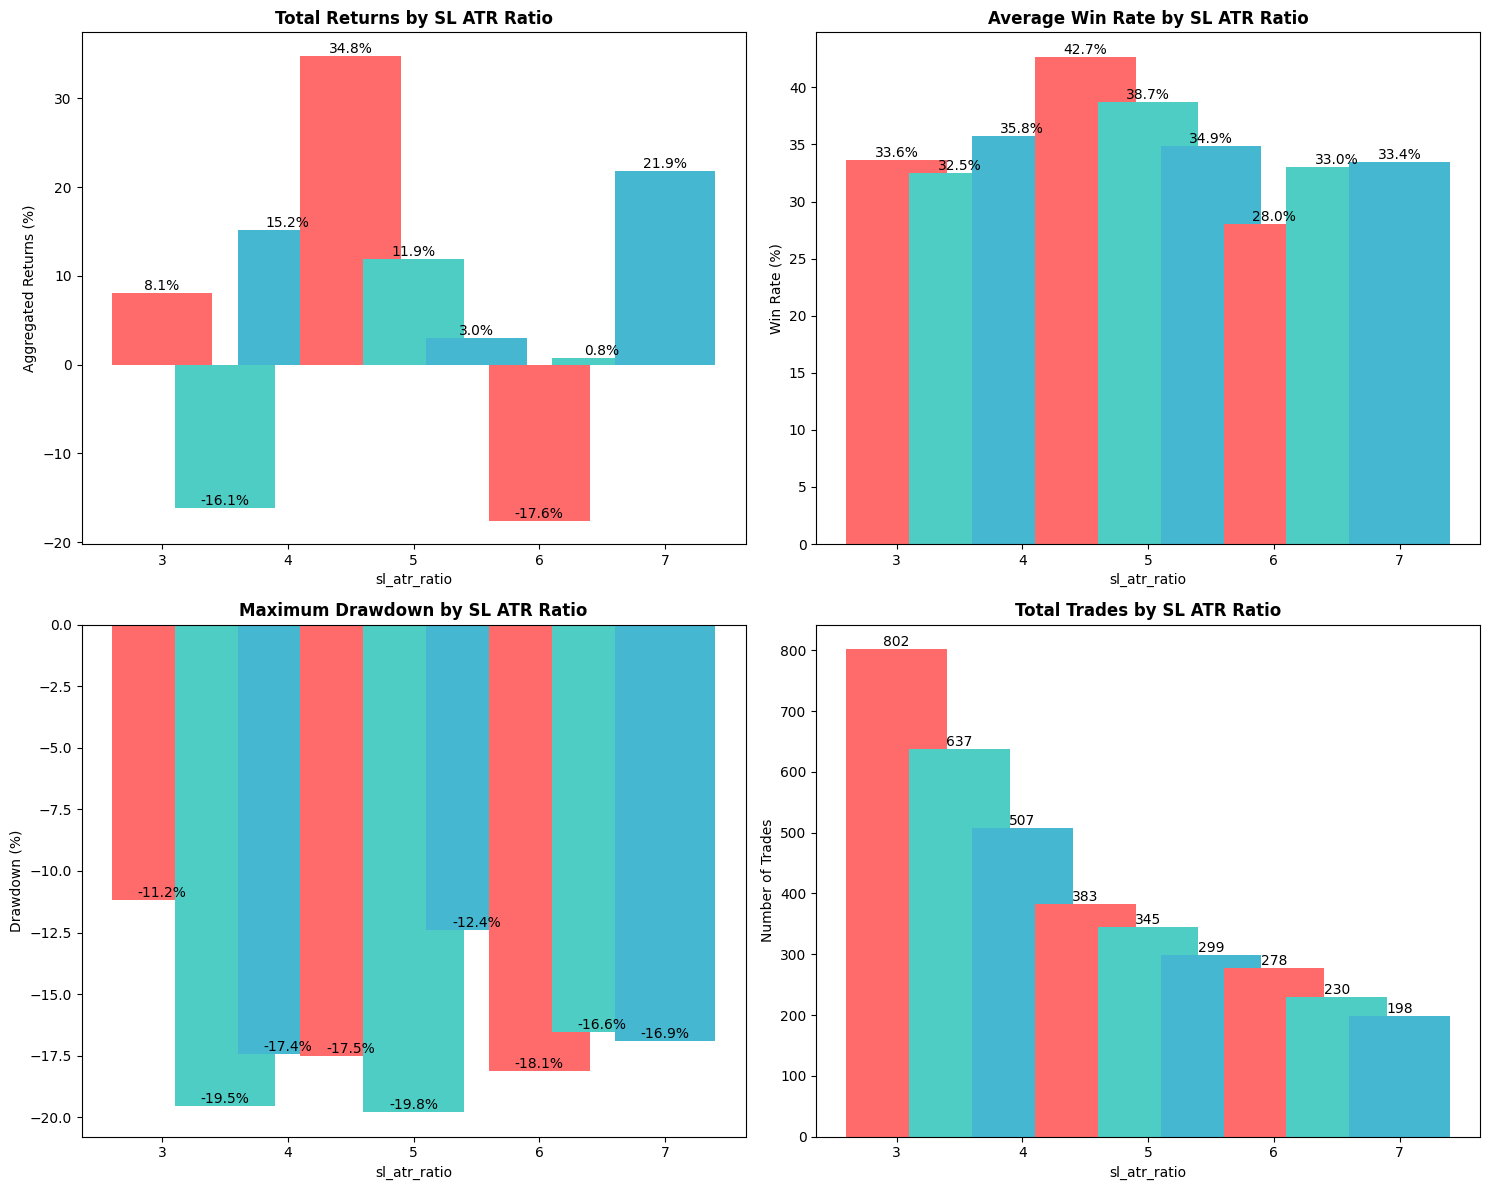

In [372]:
# Test each sl_atr_ratio value across ALL stocks
print("PERFORMANCE BY STOP-LOSS ATR RATIO (ALL STOCKS)")
print("="*60)

if 'failed_symbols' not in globals():
    failed_symbols = []
    
# We'll create separate results for each fixed ratio
ratio_performance = {3: [], 3.5:[], 4: [], 4.5: [], 5: [], 5.5:[], 6:[], 6.5:[], 7:[]}

for ratio in [3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7]:
    print(f"\nTesting sl_atr_ratio = {ratio} on all stocks...")
    
    ratio_results = []
    for i, df in enumerate(dataframes):
        if file_names[i] in failed_symbols:
            continue  # Skip previously failed symbols
            
        try:
            # Create a fixed version of the strategy for this ratio
            class FixedRatioStrat(MyStrat):
                sl_atr_ratio = ratio
            
            bt = Backtest(df, FixedRatioStrat, cash=100000, commission=0.002, finalize_trades=True)
            stats = bt.run()  # Just run, no optimization
            
            # Add the ratio to the stats for identification
            stats['sl_atr_ratio'] = ratio
            ratio_results.append(stats)
            print(f"  Processed {file_names[i]}")
            
        except Exception as e:
            print(f"  Failed {file_names[i]}: {str(e)}")
    
    ratio_performance[ratio] = ratio_results

# Now calculate metrics for each ratio across all stocks
print("\n" + "="*60)
print("PERFORMANCE COMPARISON BY FIXED SL_ATR_RATIO")
print("="*60)

for ratio in [3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7]:
    ratio_stats = ratio_performance[ratio]
    if ratio_stats:
        agg_returns = sum([r["Return [%]"] for r in ratio_stats])
        num_trades = sum([r["# Trades"] for r in ratio_stats])
        max_drawdown = min([r["Max. Drawdown [%]"] for r in ratio_stats])
        avg_drawdown = sum([r["Avg. Drawdown [%]"] for r in ratio_stats]) / len(ratio_stats)
        win_rate = sum([r["Win Rate [%]"] for r in ratio_stats]) / len(ratio_stats)
        best_trade = max([r["Best Trade [%]"] for r in ratio_stats])
        worst_trade = min([r["Worst Trade [%]"] for r in ratio_stats])
        avg_trade = sum([r["Avg. Trade [%]"] for r in ratio_stats]) / len(ratio_stats)
        
        print(f"\nsl_atr_ratio = {ratio} (Tested on {len(ratio_stats)} stocks):")
        print(f"  Aggregated Returns: {agg_returns:.2f}%")
        print(f"  Number of Trades: {num_trades}")
        print(f"  Maximum Drawdown: {max_drawdown:.2f}%")
        print(f"  Average Drawdown: {avg_drawdown:.2f}%")
        print(f"  Win Rate: {win_rate:.2f}%")
        print(f"  Best Trade: {best_trade:.2f}%")
        print(f"  Worst Trade: {worst_trade:.2f}%")
        print(f"  Average Trade: {avg_trade:.2f}%")
    else:
        print(f"\nsl_atr_ratio = {ratio}: No successful tests")

# Create comparison visualization
import matplotlib.pyplot as plt

# Prepare data for plotting
ratios = [3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7]
returns = []
win_rates = []
drawdowns = []
trade_counts = []

for ratio in ratios:
    if ratio_performance[ratio]:
        stats = ratio_performance[ratio]
        returns.append(sum([r["Return [%]"] for r in stats]))
        win_rates.append(sum([r["Win Rate [%]"] for r in stats]) / len(stats))
        drawdowns.append(min([r["Max. Drawdown [%]"] for r in stats]))
        trade_counts.append(sum([r["# Trades"] for r in stats]))

# Create comparison charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Returns comparison
ax1.bar(ratios, returns, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_title('Total Returns by SL ATR Ratio', fontweight='bold')
ax1.set_xlabel('sl_atr_ratio')
ax1.set_ylabel('Aggregated Returns (%)')
for i, v in enumerate(returns):
    ax1.text(ratios[i], v, f'{v:.1f}%', ha='center', va='bottom')

# Win Rate comparison
ax2.bar(ratios, win_rates, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax2.set_title('Average Win Rate by SL ATR Ratio', fontweight='bold')
ax2.set_xlabel('sl_atr_ratio')
ax2.set_ylabel('Win Rate (%)')
for i, v in enumerate(win_rates):
    ax2.text(ratios[i], v, f'{v:.1f}%', ha='center', va='bottom')

# Drawdown comparison
ax3.bar(ratios, drawdowns, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax3.set_title('Maximum Drawdown by SL ATR Ratio', fontweight='bold')
ax3.set_xlabel('sl_atr_ratio')
ax3.set_ylabel('Drawdown (%)')
for i, v in enumerate(drawdowns):
    ax3.text(ratios[i], v, f'{v:.1f}%', ha='center', va='bottom')

# Trade count comparison
ax4.bar(ratios, trade_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax4.set_title('Total Trades by SL ATR Ratio', fontweight='bold')
ax4.set_xlabel('sl_atr_ratio')
ax4.set_ylabel('Number of Trades')
for i, v in enumerate(trade_counts):
    ax4.text(ratios[i], v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Optimal sl_atr_ratio

Over repeated testing the `sl_atr_ratio` which yielded the highest returns on average was 5.5, averaging around 25% total returns at 13% max drawdown. sl_atr_ratio around 5 or slightly under performs similarly  




<div class="alert alert-block alert-info">
<b>♾️</b> 
The higher the ATR multiplier (sl_atr_ratio) the fewer trades are executed. But overall *time in the market* is same since we re-enter on next candle. Higher ATR is more recflective of market movement/returns
</div>

## Alternative backtest & visulization

Optimizes for `sl_atr_ratio` in range 3-6

In [373]:
results = []
heatmaps = []
failed_symbols = []

for i, df in enumerate(dataframes):
    try:
        bt = Backtest(df, MyStrat, cash=100000, commission=0.002, finalize_trades=True)
        stats, heatmap = bt.optimize(sl_atr_ratio=[i for i in range(3,6)],
                                    maximize='Return [%]', max_tries=5000,
                                    random_state=0,
                                    return_heatmap=True
                                    )
        results.append(stats)
        heatmaps.append(heatmap)
        print(f"Successfully processed {file_names[i]}")
    except AssertionError as e:
        if "Make sure 0 < price < inf!" in str(e):
            print(f"Skipping {file_names[i]} due to negative price issue")
            failed_symbols.append(file_names[i])
        else:
            raise e

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()


Backtest.optimize:   0%|          | 0/3 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/2507 [00:00<?, ?bar/s]

Successfully processed v_us_d.csv


### Calculate overall performance metrics 

In [374]:
agg_returns = sum([r["Return [%]"] for r in results])
num_trades = sum([r["# Trades"] for r in results])
max_drawdown = min([r["Max. Drawdown [%]"] for r in results])
avg_drawdown = sum([r["Avg. Drawdown [%]"] for r in results]) / len(results)

win_rate = sum([r["Win Rate [%]"] for r in results]) / len(results)
best_trade = max([r["Best Trade [%]"] for r in results])
worst_trade = min([r["Worst Trade [%]"] for r in results])
avg_trade = sum([r["Avg. Trade [%]"] for r in results]) / len(results)

print(f"Aggregated Returns: {agg_returns:.2f}%")
print(f"Number of Trades: {num_trades}")
print(f"Maximum Drawdown: {max_drawdown:.2f}%")
print(f"Average Drawdown: {avg_drawdown:.2f}%")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Best Trade: {best_trade:.2f}%")
print(f"Worst Trade: {worst_trade:.2f}%")
print(f"Average Trade: {avg_trade:.2f}%")

Aggregated Returns: 23.58%
Number of Trades: 605
Maximum Drawdown: -11.19%
Average Drawdown: -0.85%
Win Rate: 36.36%
Best Trade: 225.21%
Worst Trade: -83.81%
Average Trade: -0.06%


<div class="alert alert-block alert-danger">
<b>‼️</b> 
Only returns results for the best performing ATR multiplier (sl_atr_ratio). In contrast to prior testing, it stores it as an integer meaning it only backtests for whole numbers
</div>

### Visualize equity curves

`equity_curves` creates curves from all successful backtest results
Pad each equity curve with the first value to match the maximum length
This ensures all equity curves have the same number of data points for proper alignment

`equity_df` Create a DataFrame where each column represents a different stock's equity curve with correct padding

In [375]:
import matplotlib.pyplot as plt

equity_curves = [stats['_equity_curve']['Equity'] for stats in results]
max_length = max(len(equity) for equity in equity_curves)

# Pad each equity curve with the first value to match the maximum length
padded_equity_curves = []
for equity in equity_curves:
    first_value = equity.iloc[0]
    padding = [first_value] * (max_length - len(equity))
    padded_equity = padding + equity.tolist()
    padded_equity_curves.append(padded_equity)

equity_df = pd.DataFrame(padded_equity_curves).T

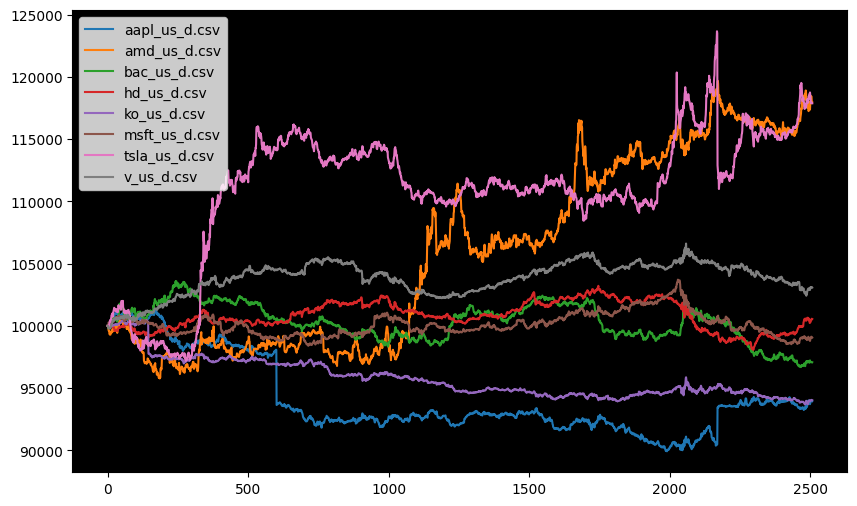

In [376]:
equity_df.plot(kind='line', figsize=(10, 6), legend=True).set_facecolor('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().tick_params(axis='x', colors='black')
plt.gca().tick_params(axis='y', colors='black')
plt.gca().set_facecolor('black')
plt.legend(file_names)

### Is this strategy *profitable*?

Over several iterations of the backtest strategy's performance is relatively consistent implying there is some strenght/value to this risk management system. However, strategy **does not beat market returns** at this stage. On average, at 15% max drawdown the system only returns ~30% over the 10 year period (5.5 ATR, accounting for 0.2% comissions) 

### What can we infer about the strategy

The backtest makes a strong case that for this strategy, assets with more significant price movement (higher volatility) may yield better performance. The random entry strategy likely capitalizes on volatility and price *break-outs*. In a highly volatile market the winning trades should, in theory, offset the more frequent losing trades-with the use of robust risk management and exit strategy

Backtest also suggests that market-correlated assets tend to perform worse than stocks with higher beta (price volatility relative to the overall market). Apple, Microsoft, Gold, as well as the S&P500 Index have all proved unprofitable on this system in over ~60% of testing. 

In theory, then, stocks with higher price volatility and other risky asset classes might be more suitable for this trading system. For this example, new portfolio will be comprised of **Biotech** companies

<div class="alert alert-block alert-warning">
<b>🔆</b> Alternatively, try using *Beta* for trading universe. Avoid biases by setting parameters and picking stocks at random. Ex.(Beta (5Y Monthly) must be between 3 and 5, Market Cap must be between $100M and $2B, US stocks >10y)
</div>




***  
 ## ***1.2 - Out of Sample Backtest***
***

"Optimal" sl_atr_ratio of **5** (explored in prior testing) backtested on a new set of data 

### Mitigating Selection Bias

Stock selection Parameters:  
Largest Biotech companies by Market Cap, US &   
Group list by 5, choose stock at random for every group (1st-5th, 6th-10th, ... 26th-30h )  

Backtest Period Selection:  
1/1/2018-1/1/2023  
Benchmark performance (S&P500):  
Annualized Return: +7.34%  
Overall Return: +42.42%  
Maximum Drawdown: -33.92%  

##### `002_b` - A, ARGX, BIIB, BMY, INSM, NVO, REGN, UTHR


In [377]:
folder_path = "./002_b"
dataframes, file_names = read_data_folder(folder_path)

for i, df in enumerate(dataframes):
    print("working on dataframe ", i, "...")
    df = add_atr(df, length=10)
    df = add_total_signal(df)
    df = add_pointpos_column(df, "TotalSignal")
    df.dropna(inplace=True)
    dataframes[i] = df  # Update the dataframe in the list
    
df

100%|██████████| 8/8 [00:00<00:00, 220.30it/s]


working on dataframe  0 ...


100%|██████████| 1259/1259 [00:00<00:00, 43603.36it/s]


working on dataframe  1 ...


100%|██████████| 1259/1259 [00:00<00:00, 45488.94it/s]


...

working on dataframe  6 ...


100%|██████████| 1259/1259 [00:00<00:00, 36534.03it/s]


working on dataframe  7 ...


100%|██████████| 1259/1259 [00:00<00:00, 41621.70it/s]


,Open,High,Low,Close,Volume,ATR,TotalSignal,pointpos
Date,,,,,,,,
2018-01-16,140.98,142.18,134.910,135.12,627901,3.840000,2,134.9099
2018-01-17,135.93,143.00,135.400,140.32,632416,4.244000,2,135.3999
2018-01-18,139.50,140.58,138.000,139.53,446979,4.077600,2,137.9999
2018-01-19,140.22,141.05,137.970,139.51,463591,3.977840,2,137.9699
2018-01-22,139.36,143.67,139.110,143.46,254760,4.036056,2,139.1099
...,...,...,...,...,...,...,...,...
2022-12-23,277.72,279.17,275.335,278.82,245750,6.600024,2,275.3349
2022-12-27,280.09,280.88,271.720,273.75,213139,6.856022,2,271.7199
2022-12-28,273.89,276.32,271.730,273.36,211262,6.629420,1,276.3201


In [378]:
sum([frame["TotalSignal"].value_counts() for frame in dataframes], start=0)

TotalSignal
1    5068
2    4930
Name: count, dtype: int64

backtest for `sl_atr_ratio` = 5 and 6

In [379]:
results2 = []
heatmaps2 = []
failed_symbols = []

for i, df in enumerate(dataframes):
    try:
        bt2 = Backtest(df, MyStrat, cash=100000, commission=0.002, finalize_trades=True)
        stats, heatmap = bt2.optimize(sl_atr_ratio=[i for i in range(5,7)],
                                    maximize='Return [%]', max_tries=5000,
                                    random_state=0,
                                    return_heatmap=True
                                    )
        results2.append(stats)
        heatmaps2.append(heatmap)
        print(f"Successfully processed {file_names[i]}")
    except AssertionError as e:
        if "Make sure 0 < price < inf!" in str(e):
            print(f"Skipping {file_names[i]} due to negative price issue")
            failed_symbols.append(file_names[i])
        else:
            raise e

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()


Backtest.optimize:   0%|          | 0/2 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/1249 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/1249 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/1249 [00:00<?, ?bar/s]

...

Backtest.optimize:   0%|          | 0/2 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/1249 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/1249 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/1249 [00:00<?, ?bar/s]

Successfully processed uthr_us_d.csv


In [380]:
agg_returns = sum([r["Return [%]"] for r in results2])
num_trades = sum([r["# Trades"] for r in results2])
max_drawdown = min([r["Max. Drawdown [%]"] for r in results2])
avg_drawdown = sum([r["Avg. Drawdown [%]"] for r in results2]) / len(results2)

win_rate = sum([r["Win Rate [%]"] for r in results2]) / len(results2)
best_trade = max([r["Best Trade [%]"] for r in results2])
worst_trade = min([r["Worst Trade [%]"] for r in results2])
avg_trade = sum([r["Avg. Trade [%]"] for r in results2]) / len(results2)

print(f"Aggregated Returns: {agg_returns:.2f}%")
print(f"Number of Trades: {num_trades}")
print(f"Maximum Drawdown: {max_drawdown:.2f}%")
print(f"Average Drawdown: {avg_drawdown:.2f}%")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Best Trade: {best_trade:.2f}%")
print(f"Worst Trade: {worst_trade:.2f}%")
print(f"Average Trade: {avg_trade:.2f}%")

Aggregated Returns: -4.37%
Number of Trades: 149
Maximum Drawdown: -8.77%
Average Drawdown: -1.19%
Win Rate: 41.52%
Best Trade: 62.48%
Worst Trade: -43.63%
Average Trade: -1.39%


sl_atr_ratio
5               1.660046
6              -3.471945
Name: Return [%], dtype: float64

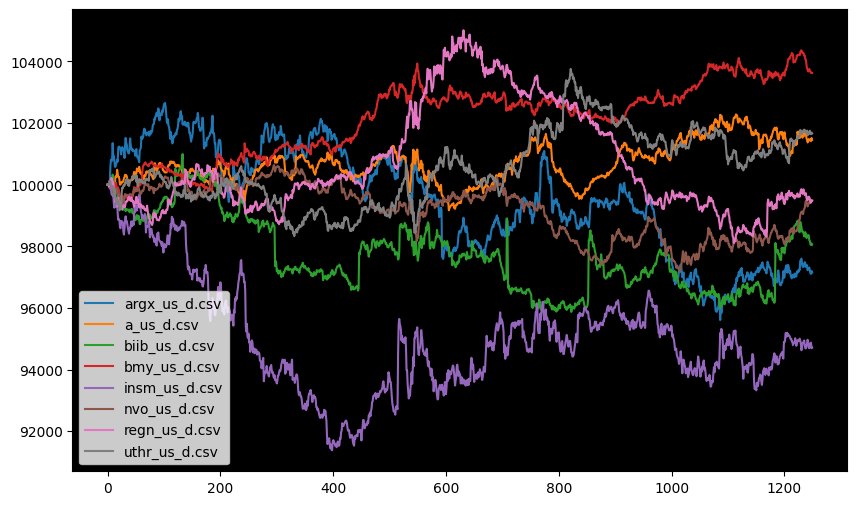

In [381]:
equity_curves = [stats['_equity_curve']['Equity'] for stats in results2]
max_length = max(len(equity) for equity in equity_curves)

# Pad each equity curve with the first value to match the maximum length
padded_equity_curves = []
for equity in equity_curves:
    first_value = equity.iloc[0]
    padding = [first_value] * (max_length - len(equity))
    padded_equity = padding + equity.tolist()
    padded_equity_curves.append(padded_equity)

equity_df = pd.DataFrame(padded_equity_curves).T

equity_df.plot(kind='line', figsize=(10, 6), legend=True).set_facecolor('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().tick_params(axis='x', colors='black')
plt.gca().tick_params(axis='y', colors='black')
plt.gca().set_facecolor('black')
plt.legend(file_names)

heatmap

### Aggregated equity curve

Plot cummulative equity curve instead of individual lines

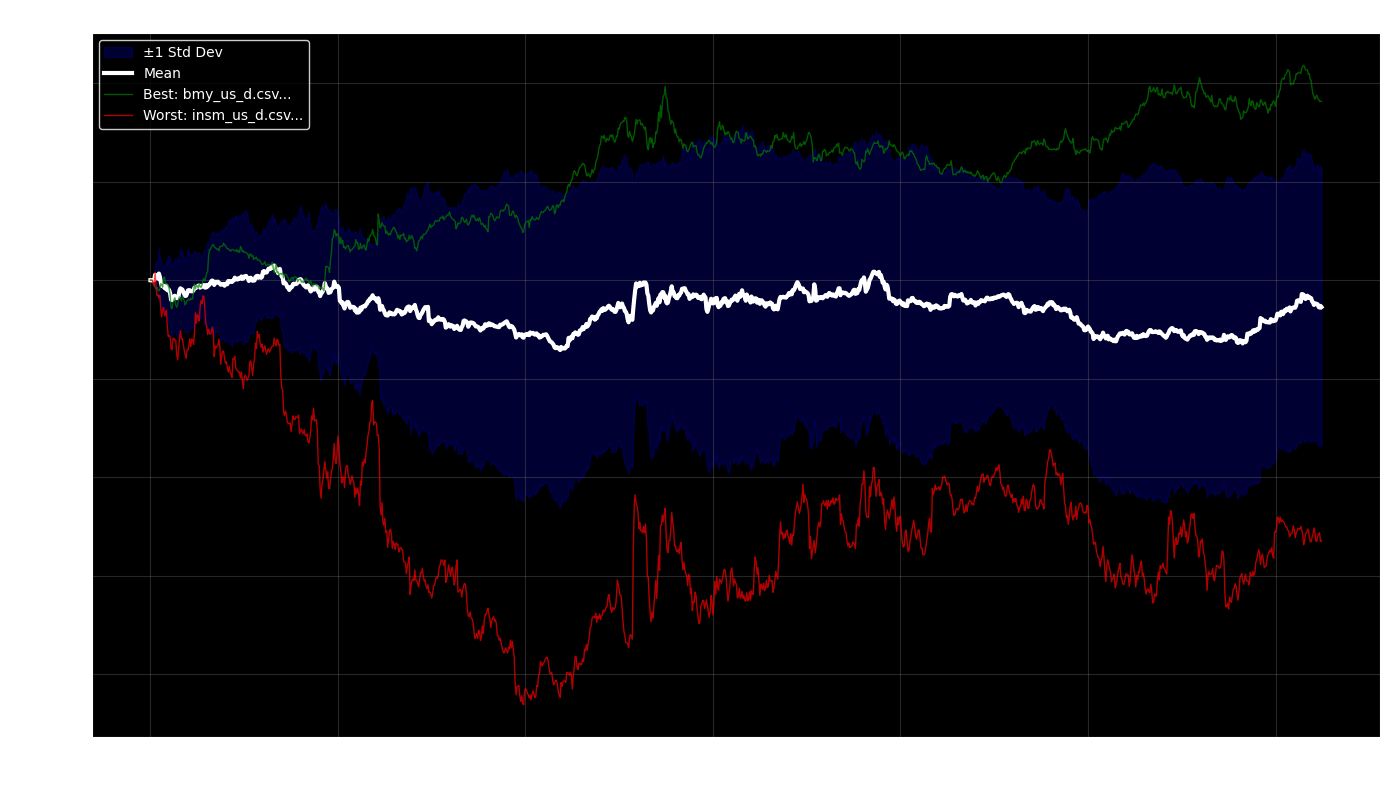

In [382]:
# Plot statistical summary
plt.figure(figsize=(14, 8))
ax = plt.subplot(111)

# Calculate statistics
mean_equity = equity_df.mean(axis=1)
std_equity = equity_df.std(axis=1)

upper_bound = mean_equity + std_equity
lower_bound = mean_equity - std_equity

# Plot with confidence band
plt.fill_between(equity_df.index, lower_bound, upper_bound, 
                 color='blue', alpha=0.2, label='±1 Std Dev')
plt.plot(equity_df.index, mean_equity, 'white', linewidth=3, label='Mean')

# Best and worst performing stocks
best_stock = equity_df.iloc[-1].idxmax()  # Stock with highest final equity
worst_stock = equity_df.iloc[-1].idxmin() # Stock with lowest final equity

plt.plot(equity_df.index, equity_df[best_stock], 'green', 
         linewidth=1, alpha=0.7, label=f'Best: {file_names[best_stock][:20]}...')
plt.plot(equity_df.index, equity_df[worst_stock], 'red', 
         linewidth=1, alpha=0.7, label=f'Worst: {file_names[worst_stock][:20]}...')

# Styling
ax.set_facecolor('black')
for spine in ax.spines.values():
    spine.set_color('white')
ax.tick_params(colors='white')

plt.title('Portfolio Equity Curve with Statistics', color='white', fontsize=14)
plt.xlabel('Time Period', color='white')
plt.ylabel('Account Equity ($)', color='white')
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')
plt.grid(True, color='gray', alpha=0.3)

plt.tight_layout()
plt.show()

## Can you remain profitable with only random entries?

Although this notebook does not support conculsive evidence nor a perfect overview of the system, results indicate this strategy  **can be profitable**. 
The average performance of this backtest, however, rarely came close to beating benchmark returns, while the max drawdown typically ranged from 4-10%

A random entry with a volatility-based trailing stop seem to be profitable over large sample sizes assuming the underdying assets demonstrates "tendency to trend"-characteristic that many commodities do share. The dicrepency in results and variance from first testing could be explained by faster price movement and hence more stop-loss triggers and more trades being entered and comissioned


<div class="alert alert-block alert-info">
<b>♾️</b> 
While a purely random entry strategy may be viable on paper, it is impractical and tough to stomach in real life.  It is feasible to achieve significantly better results with non-random signals without dedicating excessive time to 'perfecting' that signal
</div>


# Just how random was Basso's system?

Clearly, all trades are random in direction, time and price. But the markets weren't randomly selected. (Although individual stocks were picked at random, large-cap as well as biotech stocks exhibit *trendiness* similar to futures contracts used in Basso's original study.) And lastly, the exits definitely weren't random.  

Hence, Basso was not testing a purely random system. And obtaining decent results by merely flipping a coin to decide when to get in and when to get out is unlikely.


## Strategy improvements

Stock selection:
Filter for biotech companies younger than 25 years
High Beta stock, ex. Beta (5Y Monthly) must be between 3 and 5, filter by market cap

Incorporate entry signal:
Use volume/MA/market trend as signal confirmation, else wait to entry at favorable position  
Entry indicators may test differently for various timeframes - different ranges for price movement

[Pure random random entry](https://www.nasdaq.com/articles/revisiting-tom-basso-how-important-your-entry-trading-part-2-2016-11-12) (add even more randomness)

***

### *CREDITS*

**Tharp. Van K.**, Trade Your Way to Financial Freedom 2nd Edition   
*McGraw-Hill*, 1998

[@CodeTradingCafe](https://www.youtube.com/@CodeTradingCafe)   

DISCLAIMER: The information contained in this channel is presented for educational purposes ONLY, I am NOT a financial expert nor a financial consultant, if you decide to use any of the content of this channel you may do so at your own responsibility. Although I do my best to provide reliable information I am NOT responsible for any losses incurred due to any trading systems presented on this channel.